In [1]:
import os
os.chdir(r"C:\Users\mattc\OneDrive\Documents\eso8GKofnumUkahs")
os.getcwd()

'C:\\Users\\mattc\\OneDrive\\Documents\\eso8GKofnumUkahs'

In [2]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from matplotlib import pyplot as plt
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report, make_scorer

from src.data.prepare_data import x_y_split, tt_split

In [3]:
random_state = 42
np.random.seed(random_state)
print('Random Seed:')
print(random_state)

Random Seed:
42


In [6]:
data = pd.read_csv('data/raw/ACME-HappinessSurvey2020.csv')
x, y = x_y_split(data)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


### BNB Classifier Report

Best Parameters:
{'alpha': 0.01, 'binarize': 4, 'fit_prior': True}
Testing Data Accuracy:
0.69
              precision    recall  f1-score   support

           0       0.70      0.58      0.64        12
           1       0.69      0.79      0.73        14

    accuracy                           0.69        26
   macro avg       0.69      0.68      0.68        26
weighted avg       0.69      0.69      0.69        26



### Confusion Matrix

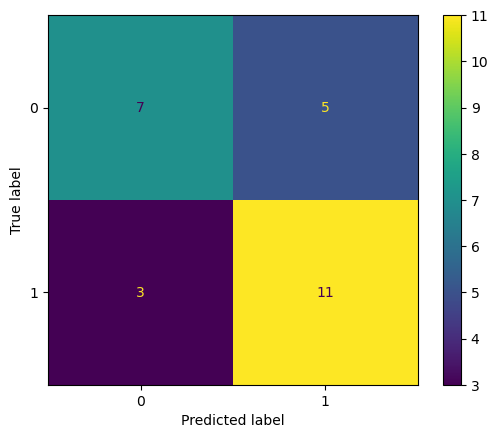

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=random_state, stratify=y)

param_grid = {
    'alpha': [0.01, 0.1, 1],
    'binarize': [1, 2, 3, 4],
    'fit_prior': [True, False]
}
  
bnb_grid = GridSearchCV(
    BernoulliNB(),
    param_grid,
    cv=3, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

bnb_grid.fit(x_train, y_train)
bnb_model = bnb_grid.best_estimator_

y_pred = bnb_model.predict(x_test)

display(Markdown('### BNB Classifier Report'))

print('Best Parameters:')
print(bnb_grid.best_params_)

print('Testing Data Accuracy:')
print(round(accuracy_score(y_test, y_pred), 2))

print(classification_report(y_test, y_pred))

display(Markdown('### Confusion Matrix'))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()